In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

## Loading the Dataset
Loading the Tesla deliveries CSV and doing a quick check for nulls and data types.


In [14]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

print(df.shape)
print(df.head())
print("\nNull values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)

(2640, 12)
   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)               7640  


## Preprocessing
Creating a proper Date column, sorting chronologically, and encoding the categorical columns.

In [15]:
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(Day=1))
df = df.sort_values('Date').reset_index(drop=True)

df = pd.get_dummies(df, columns=['Region', 'Model', 'Source_Type'], drop_first=True)

print(df.shape)
print(df.head())

(2640, 19)
   Year  Month  Estimated_Deliveries  Production_Units  Avg_Price_USD  \
0  2015      1                 12446             13885       55183.13   
1  2015      1                 11446             12752       89289.40   
2  2015      1                  8803              9344      102888.58   
3  2015      1                  6367              6802      104962.32   
4  2015      1                  8795              9165       87988.73   

   Battery_Capacity_kWh  Range_km  CO2_Saved_tons  Charging_Stations  \
0                    60       340          634.75               4390   
1                   100       588         1009.54               8925   
2                    60       336          443.67               3923   
3                    82       459          438.37               9170   
4                    82       456          601.58              12626   

        Date  Region_Europe  Region_Middle East  Region_North America  \
0 2015-01-01          False               Fa

## EDA
Quick look at yearly delivery trends and how each region is performing overall.

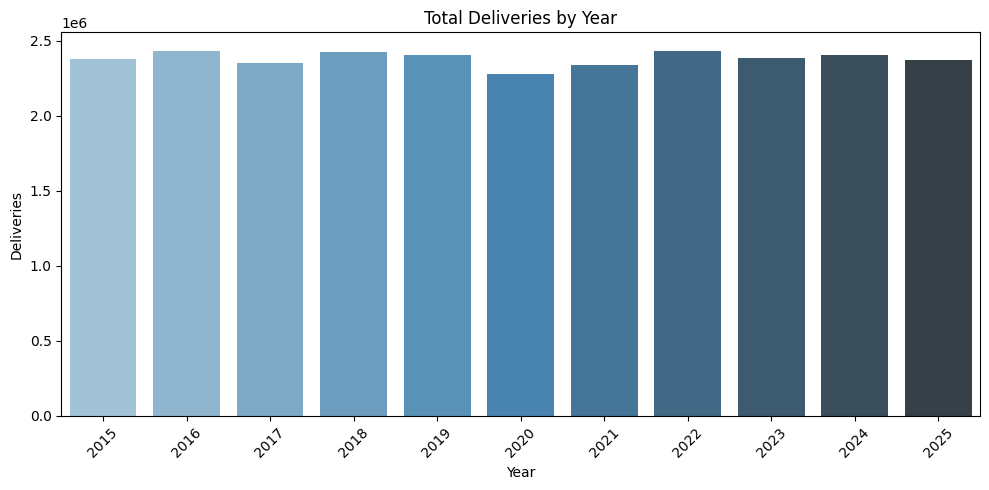

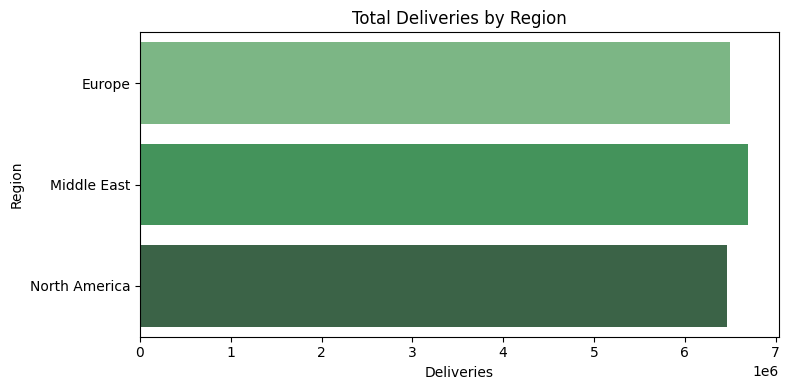

In [16]:
yearly = df.groupby('Year')['Estimated_Deliveries'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=yearly, x='Year', y='Estimated_Deliveries', palette='Blues_d')
plt.title('Total Deliveries by Year')
plt.xlabel('Year')
plt.ylabel('Deliveries')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

region_cols = [c for c in df.columns if c.startswith('Region_')]
region_totals = {col.replace('Region_', ''): df[df[col] == 1]['Estimated_Deliveries'].sum() for col in region_cols}
region_df = pd.DataFrame(list(region_totals.items()), columns=['Region', 'Total_Deliveries'])

plt.figure(figsize=(8, 4))
sns.barplot(data=region_df, y='Region', x='Total_Deliveries', palette='Greens_d')
plt.title('Total Deliveries by Region')
plt.xlabel('Deliveries')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

## Feature Engineering
Added CO2 per delivery, price per km, and lag/rolling features on production units to give the models more to work with.

In [17]:
df['co2_per_delivery'] = df['CO2_Saved_tons'] / df['Estimated_Deliveries']
df['price_per_km']     = df['Avg_Price_USD'] / df['Range_km']

region_model_group = df.groupby(['Year', 'Month'])

df['lag_1'] = df.groupby(['Year'])['Production_Units'].shift(1)
df['lag_2'] = df.groupby(['Year'])['Production_Units'].shift(2)

df['roll_3'] = (
    df.groupby(['Year'])['Production_Units']
    .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
)

df = df.dropna(subset=['lag_1', 'lag_2', 'roll_3']).reset_index(drop=True)

print(f"Shape after feature engineering: {df.shape}")
print(df[['Production_Units', 'lag_1', 'lag_2', 'roll_3', 'co2_per_delivery', 'price_per_km']].head(8))

Shape after feature engineering: (2618, 24)
   Production_Units    lag_1    lag_2        roll_3  co2_per_delivery  \
0              9344  12752.0  13885.0  13318.500000          0.050400   
1              6802   9344.0  12752.0  11993.666667          0.068850   
2              9165   6802.0   9344.0   9632.666667          0.068400   
3              2465   9165.0   6802.0   8437.000000          0.104248   
4             13302   2465.0   9165.0   6144.000000          0.068550   
5              8878  13302.0   2465.0   8310.666667          0.069150   
6              9528   8878.0  13302.0   8215.000000          0.065250   
7              4736   9528.0   8878.0  10569.333333          0.071251   

   price_per_km  
0    306.216012  
1    228.676078  
2    192.957741  
3    162.068935  
4    201.107418  
5    246.534555  
6    254.327195  
7    112.108484  


## Hyperparameter Tuning
Random Forest did better so tuning it further with RandomizedSearchCV. Trying different tree depths, estimator counts and split settings across 3-fold CV.

In [18]:
feature_cols = [
    'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh',
    'Range_km', 'Charging_Stations',
    'co2_per_delivery', 'price_per_km',
    'lag_1', 'lag_2', 'roll_3'
]

dummy_cols = [c for c in df.columns if c.startswith('Region_') or
              c.startswith('Model_') or c.startswith('Source_')]

X = df[feature_cols + dummy_cols]
y = df['Estimated_Deliveries']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

rf_model = RandomForestRegressor(n_estimators=50, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_r2    = r2_score(y_test, rf_preds)
rf_mae   = mean_absolute_error(y_test, rf_preds)

param_dist = {
    'n_estimators'     : [50, 100, 200, 300],
    'max_depth'        : [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'max_features'     : ['sqrt', 'log2', 0.5]
}

rf_tuned = RandomizedSearchCV(
    estimator           = RandomForestRegressor(random_state=42),
    param_distributions = param_dist,
    n_iter              = 20,
    cv                  = 3,
    scoring             = 'neg_mean_absolute_error',
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 1
)

rf_tuned.fit(X_train, y_train)

print("Best parameters:")
for param, val in rf_tuned.best_params_.items():
    print(f"  {param}: {val}")

tuned_preds = rf_tuned.best_estimator_.predict(X_test)
tuned_r2    = r2_score(y_test, tuned_preds)
tuned_mae   = mean_absolute_error(y_test, tuned_preds)

print(f"\nTuned RF    — R²: {tuned_r2:.4f} | MAE: {tuned_mae:.2f}")
print(f"Baseline RF — R²: {rf_r2:.4f} | MAE: {rf_mae:.2f}")
print(f"Improvement : {rf_mae - tuned_mae:.2f} units")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters:
  n_estimators: 300
  min_samples_split: 2
  max_features: 0.5
  max_depth: None

Tuned RF    — R²: 0.9845 | MAE: 367.87
Baseline RF — R²: 0.9844 | MAE: 364.16
Improvement : -3.72 units


## Ridge & Lasso Regression
Tried Ridge and Lasso on top of Linear Regression to see if regularization helps. Lasso also does some automatic feature selection which is useful here given the number of columns.

In [19]:
from sklearn.linear_model import Ridge, Lasso

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
ridge_preds = ridge_model.predict(X_test)
ridge_r2    = r2_score(y_test, ridge_preds)
ridge_mae   = mean_absolute_error(y_test, ridge_preds)

lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train, y_train)
lasso_preds = lasso_model.predict(X_test)
lasso_r2    = r2_score(y_test, lasso_preds)
lasso_mae   = mean_absolute_error(y_test, lasso_preds)

print(f"{'Metric':<20} {'Ridge':>15} {'Lasso':>15}")
print("-" * 52)
print(f"{'R² Score':<20} {ridge_r2:>15.4f} {lasso_r2:>15.4f}")
print(f"{'MAE':<20} {ridge_mae:>15.2f} {lasso_mae:>15.2f}")

Metric                         Ridge           Lasso
----------------------------------------------------
R² Score                      0.9862          0.9862
MAE                           354.27          353.53


## Cross Validation
Used 5-fold cross validation on the tuned Random Forest to make sure the model generalizes well and isn't just performing well on one particular split.

In [20]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_tuned.best_estimator_,
    X, y,
    cv      = 5,
    scoring = 'r2'
)

print(f"CV R² Scores across 5 folds: {cv_scores.round(4)}")
print(f"Mean R²  : {cv_scores.mean():.4f}")
print(f"Std Dev  : {cv_scores.std():.4f}")

CV R² Scores across 5 folds: [0.9782 0.9829 0.985  0.9861 0.9839]
Mean R²  : 0.9832
Std Dev  : 0.0027


## Feature Importance
Plotted which features the Random Forest relied on the most. Helps understand what's actually driving the delivery predictions.

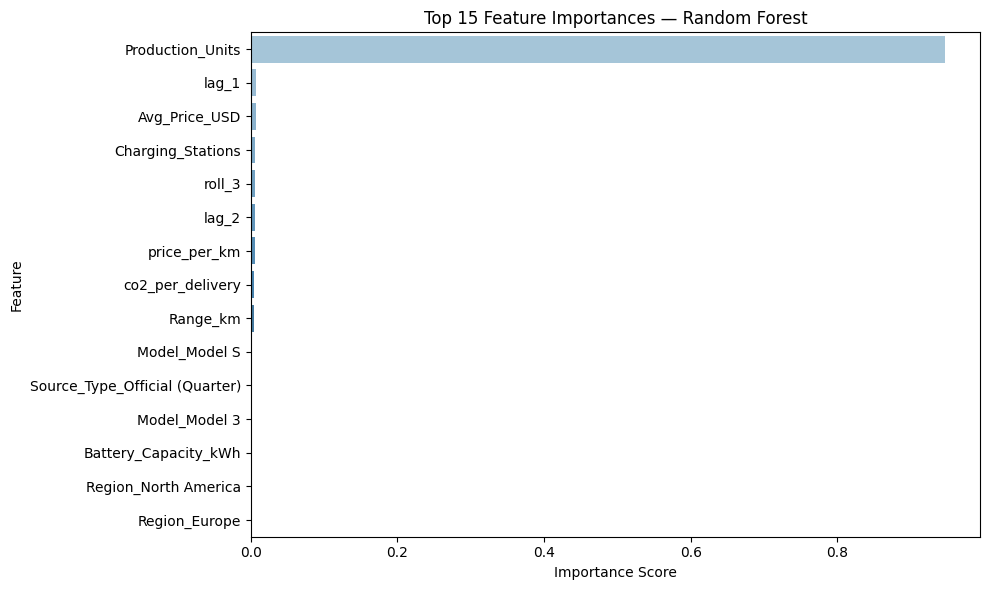

In [21]:
importances = rf_tuned.best_estimator_.feature_importances_
feature_names = feature_cols + dummy_cols

importance_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='Blues_d')
plt.title('Top 15 Feature Importances — Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()